In [3]:
import sys; sys.path.append('..')
import parametrization, sparse_matrices, mesh, numpy as np, importlib, pickle, wall_generation, inflation
from numpy.linalg import norm
import fd_validation, time

target_surface = mesh.Mesh("../../examples/squidward_remesh.obj")
target_surface = target_surface.subdivide_loop(1)

m = mesh.Mesh('../results/squidward/top_sheet_f3.75.msh')
fuseMarkers = np.loadtxt('../results/squidward/fuse_markers_f3.75.txt')

isheet = inflation.InflatableSheet(m, np.array(fuseMarkers) != 0)
bv = isheet.mesh().boundaryVertices()
bdryVars = [isheet.varIdx(0, i, c) for i in bv for c in range(3)]

isheet.setVars(np.loadtxt('../squidward_neohookean_equilibrium.txt'))

# perturb = np.random.uniform(-1.0, 1.0, isheet.numVars())
perturb = np.loadtxt('perturb.txt')

In [4]:
isheet.setUseTensionFieldEnergy(False)
isheet.pressure = 0.25
isheet.energy(energyType=isheet.EnergyType.Pressure)

-362.60046682815592467

In [8]:
isheet.setUseTensionFieldEnergy(False)
isheet.pressure = 0.25
isheet.energy(energyType=isheet.EnergyType.Pressure)

-362.60046682815596

In [3]:
-1087.8014004 / -362.600466

3.0000000066188552

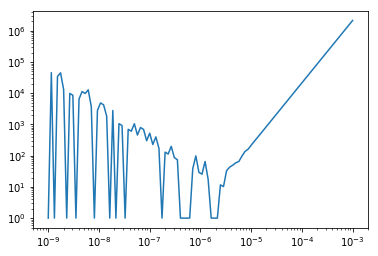

In [15]:
eps, errors, an_full = fd_validation.gradConvergence(isheet, energyType=isheet.EnergyType.Full, perturb=perturb, fixedVars=bdryVars)
from matplotlib import pyplot as plt
plt.loglog(eps, errors)
plt.show()

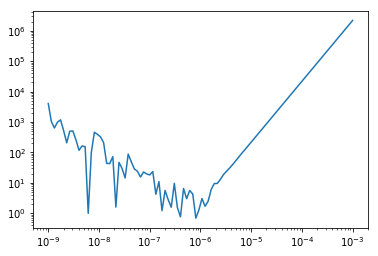

In [4]:
eps, errors, an_full = fd_validation.gradConvergence(isheet, energyType=isheet.EnergyType.Full, perturb=perturb, fixedVars=bdryVars)
from matplotlib import pyplot as plt
plt.loglog(eps, errors)
plt.show()

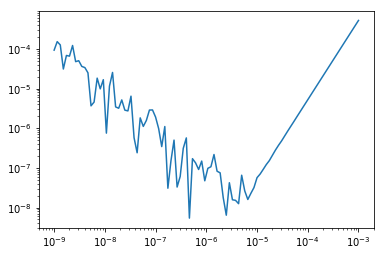

8.600221633911133

In [4]:
start = time.time()
eps, errors, an_full = fd_validation.gradConvergence(isheet, energyType=isheet.EnergyType.Elastic, perturb=perturb, fixedVars=bdryVars)
from matplotlib import pyplot as plt
plt.loglog(eps, errors)
plt.show()
time.time() - start

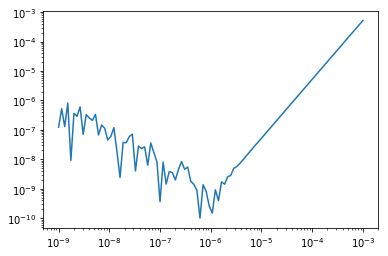

9.976465940475464

In [6]:
start = time.time()
eps, errors, an_full = fd_validation.gradConvergence(isheet, energyType=isheet.EnergyType.Elastic, perturb=perturb, fixedVars=bdryVars)
from matplotlib import pyplot as plt
plt.loglog(eps, errors)
plt.show()
time.time() - start

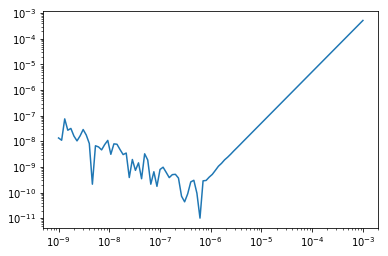

11.390005111694336

In [4]:
start = time.time()
eps, errors, an_full = fd_validation.gradConvergence(isheet, energyType=isheet.EnergyType.Elastic, perturb=perturb, fixedVars=bdryVars)
from matplotlib import pyplot as plt
plt.loglog(eps, errors)
plt.show()
time.time() - start

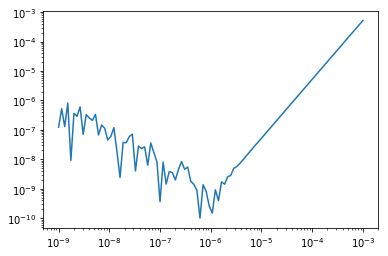

10.197824716567993

In [5]:
start = time.time()
eps, errors, an_full = fd_validation.gradConvergence(isheet, energyType=isheet.EnergyType.Elastic, perturb=perturb, fixedVars=bdryVars)
from matplotlib import pyplot as plt
plt.loglog(eps, errors)
plt.show()
time.time() - start

In [8]:
an_full

-4.4442728995950976575

In [12]:
pe = isheet.energy(energyType=isheet.EnergyType.Pressure)

In [13]:
pe?

Type:        float
String form: -362.6004668281559
Docstring:   Convert a string or number to a floating point number, if possible.


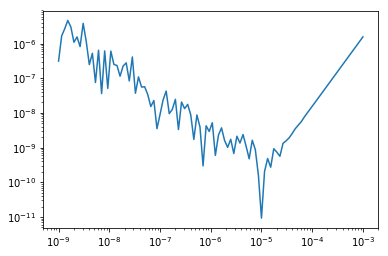

6.155638933181763

In [5]:
start = time.time()
eps, errors, an_full = fd_validation.gradConvergence(isheet, energyType=isheet.EnergyType.Pressure, perturb=perturb, fixedVars=bdryVars)
from matplotlib import pyplot as plt
plt.loglog(eps, errors)
plt.show()
time.time() - start

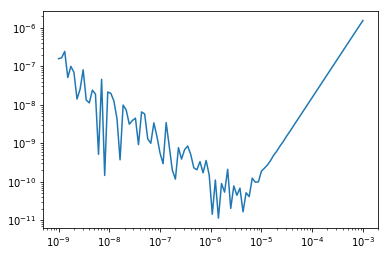

7.9840991497039795

In [6]:
start = time.time()
eps, errors, an_full = fd_validation.gradConvergence(isheet, energyType=isheet.EnergyType.Pressure, perturb=perturb, fixedVars=bdryVars)
from matplotlib import pyplot as plt
plt.loglog(eps, errors)
plt.show()
time.time() - start

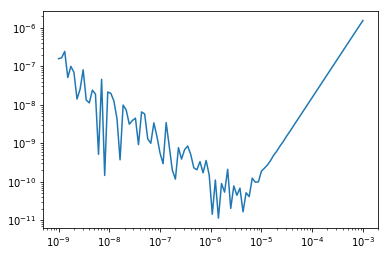

8.987381935119629

In [7]:
start = time.time()
eps, errors, an_full = fd_validation.gradConvergence(isheet, energyType=isheet.EnergyType.Pressure, perturb=perturb, fixedVars=bdryVars)
from matplotlib import pyplot as plt
plt.loglog(eps, errors)
plt.show()
time.time() - start

InflatableSheet energy	0.901864	200
InflatableSheet gradient	2.86578	100
InflatableSheet setVars	3.04369	400
Full time	7.23057


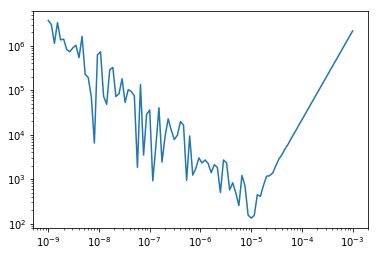

In [4]:
inflation.benchmark_reset()
eps, errors, an_full = fd_validation.gradConvergence(isheet, energyType=isheet.EnergyType.Full, perturb=perturb, fixedVars=bdryVars)
inflation.benchmark_report()
from matplotlib import pyplot as plt
plt.loglog(eps, errors)
plt.show()

InflatableSheet energy	1.26931	200
InflatableSheet gradient	2.28773	100
InflatableSheet setVars	4.43692	400
Full time	8.59871


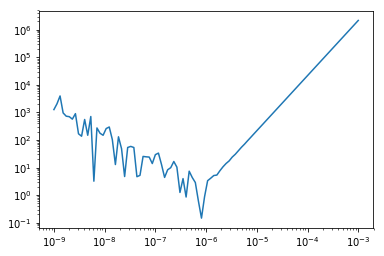

In [4]:
inflation.benchmark_reset()
eps, errors, an_full = fd_validation.gradConvergence(isheet, energyType=isheet.EnergyType.Full, perturb=perturb, fixedVars=bdryVars)
inflation.benchmark_report()
from matplotlib import pyplot as plt
plt.loglog(eps, errors)
plt.show()

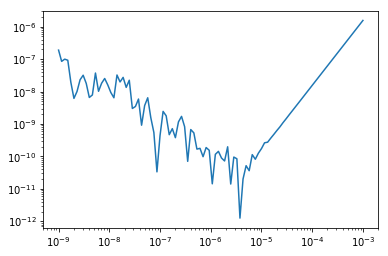

InflatableSheet energy	0.712526	200
InflatableSheet gradient	0.548802	100
InflatableSheet setVars	3.65431	400
Full time	6.42773


In [5]:
inflation.benchmark_reset()
eps, errors, an_full = fd_validation.gradConvergence(isheet, energyType=isheet.EnergyType.Pressure, perturb=perturb, fixedVars=bdryVars)
from matplotlib import pyplot as plt
plt.loglog(eps, errors)
plt.show()
inflation.benchmark_report()

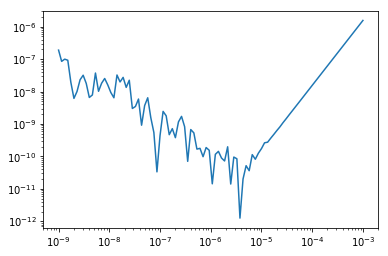

InflatableSheet energy	0.707042	200
InflatableSheet gradient	0.41887	100
InflatableSheet setVars	3.65611	400
Full time	5.96047


In [7]:
inflation.benchmark_reset()
eps, errors, an_full = fd_validation.gradConvergence(isheet, energyType=isheet.EnergyType.Pressure, perturb=perturb, fixedVars=bdryVars)
from matplotlib import pyplot as plt
plt.loglog(eps, errors)
plt.show()
inflation.benchmark_report()

InflatableSheet energy	0.630289	200
InflatableSheet gradient	2.90058	100
InflatableSheet setVars	3.65097	400
Full time	7.55712


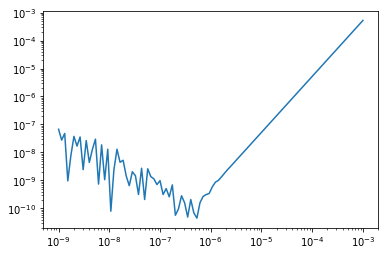

In [6]:
inflation.benchmark_reset()
eps, errors, an_full = fd_validation.gradConvergence(isheet, energyType=isheet.EnergyType.Elastic, perturb=perturb, fixedVars=bdryVars)
inflation.benchmark_report()
from matplotlib import pyplot as plt
plt.loglog(eps, errors)
plt.show()

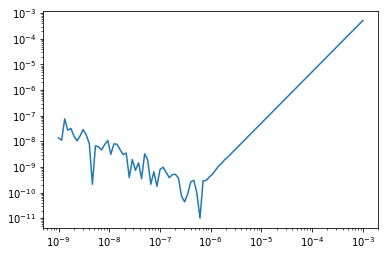

InflatableSheet energy	0.562946	200
InflatableSheet gradient	1.84204	100
InflatableSheet setVars	4.55372	400
Full time	8.5933


In [7]:
inflation.benchmark_reset()
eps, errors, an_full = fd_validation.gradConvergence(isheet, energyType=isheet.EnergyType.Elastic, perturb=perturb, fixedVars=bdryVars)
from matplotlib import pyplot as plt
plt.loglog(eps, errors)
plt.show()
inflation.benchmark_report()

In [11]:
perturb_nonbdry = perturb.copy()
perturb_nonbdry[bdryVars] = 0.0

In [7]:
np.dot(isheet.gradient(energyType=isheet.EnergyType.Pressure), perturb_nonbdry)

4.444272900669044

In [8]:
fd_validation.fdGrad(isheet, fd_eps=1e-4, etype=isheet.EnergyType.Pressure, perturb=perturb, fixedVars=bdryVars)

4.4442728301419265

In [14]:
fd_validation.fdGrad(isheet, fd_eps=1e-5, etype=isheet.EnergyType.Pressure, perturb=perturb, fixedVars=bdryVars)

4.444272900627766

In [9]:
currVars = isheet.getVars()

In [24]:
fd_eps = 1e-5
etype=isheet.EnergyType.Pressure
isheet.setVars(currVars + fd_eps * perturb_nonbdry); ePlus  = isheet.energy(energyType=etype)
isheet.setVars(currVars - fd_eps * perturb_nonbdry); eMinus = isheet.energy(energyType=etype)
isheet.setVars(currVars)
print(ePlus, eMinus)

-362.60042238519371371 -362.60051127065171014


In [35]:
np.log10(2**53)

15.954589770191003

In [5]:
np.log10(2) * (64 - 53)

3.3113299523037933

In [25]:
isheet.energy(isheet.EnergyType.Elastic)

80.96934606010840379

In [30]:
ePlus - eMinus

8.8885457996429328986e-05

In [31]:
(ePlus - eMinus) / (2 * fd_eps)

4.444272899821466086

In [32]:
an_full

4.44427290066900974

In [33]:
((ePlus - eMinus) / (2 * fd_eps) - an_full) / an_full

-1.907046828863397004e-10